In [ ]:
!pip install pandas

In [ ]:
!pip install pm4py

In [ ]:
!pip install matplotlib

In [ ]:
!pip install seaborn

In [2]:
import pandas as pd
import pm4py
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from datetime import timedelta
import warnings
import numpy as np
from pm4py.algo.discovery.dfg import algorithm as dfg_discovery
from pm4py.visualization.dfg import visualizer as dfg_visualization
from pm4py.util import constants
warnings.filterwarnings('ignore')

# Visualization configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
COLORS = {'primary': '#2E86AB', 'secondary': '#A23B72', 'accent': '#F18F01', 
          'success': '#C73E1D', 'neutral': '#3B1F2B'}

## 1. Preprocessing

###1.1 Formatting columns for the compatibility with pm4py

In [3]:
df = pd.read_csv("../event_log.csv")

complete_log = df.rename(columns={
    "stay_id": "case:concept:name",
    "activity": "concept:name",
    "time": "time:timestamp",
    "arrival_transport": "case:arrival_transport",
    "disposition" : 'case:disposition',
    "gender": "case:gender",
    "race": "case:race",
    "acuity": "case:acuity",
    "chiefcomplaint": "case:chiefcomplaint"
})

# convert the 'Date' column to datetime format
complete_log['time:timestamp']= pd.to_datetime(complete_log['time:timestamp'])

# The case ID column should be of type string
complete_log['case:concept:name'] = complete_log['case:concept:name'].astype(str)


### 1.2 Checking for missing data in case level attributes

In [4]:
case_attributes = [
    "case:concept:name",
    "case:arrival_transport",
    "case:disposition",
    "case:gender",
    "case:race",
    "case:acuity",
    "case:chiefcomplaint"
]


# Group by Case ID and take the first value found
grouped_by_case_log = complete_log[case_attributes].groupby("case:concept:name").first()

# 1. Basic Counts and Percentages
missing_count = grouped_by_case_log.isnull().sum()
missing_pct = (grouped_by_case_log.isnull().sum() / len(grouped_by_case_log)) * 100

# Combine into a clear report
missing_report = pd.DataFrame({
    'Missing Values': missing_count,
    'Percentage': missing_pct
}).sort_values(by='Percentage', ascending=False)

print(missing_report)

                        Missing Values  Percentage
case:acuity                         56    3.076923
case:arrival_transport               0    0.000000
case:disposition                     0    0.000000
case:gender                          0    0.000000
case:race                            0    0.000000
case:chiefcomplaint                  0    0.000000


### 1.3 Handling missing data in case level attributes
Case-level missing data analysis showed very low missingness across most attributes. Only acuity exhibited moderate missingness (3.08%), which was handled by introducing an explicit ‘Unknown’ category to avoid clinically unjustified imputation. Diagnosis-related attributes had negligible missingness (<0.2%) and were retained, with missing values flagged for downstream attribute-based analyses.

In [5]:
complete_log["case:acuity"] = complete_log["case:acuity"].fillna("N/A")

### 1.4 Case-Level Coverage of Activity Attributes

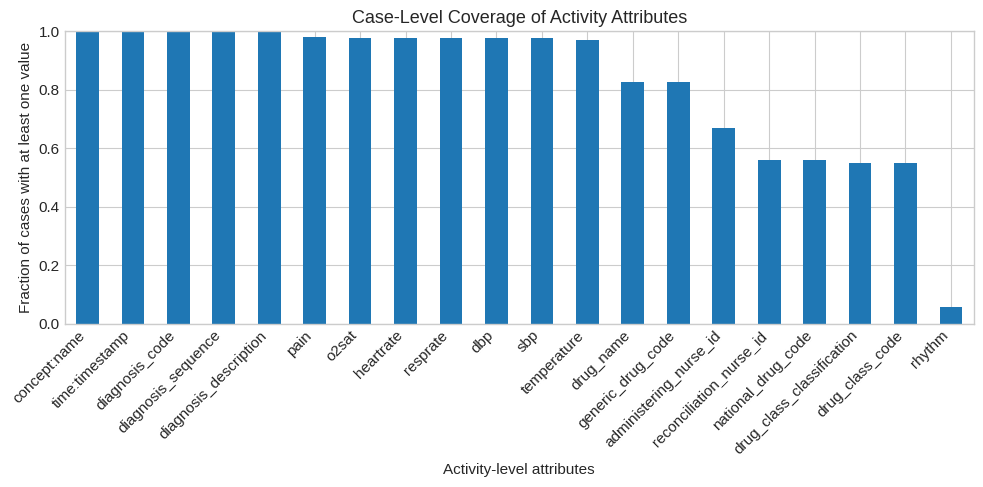

concept:name                 1.000000
time:timestamp               1.000000
diagnosis_code               0.998352
diagnosis_sequence           0.998352
diagnosis_description        0.998352
pain                         0.980769
o2sat                        0.978022
heartrate                    0.978022
resprate                     0.978022
dbp                          0.977473
sbp                          0.977473
temperature                  0.970879
drug_name                    0.828022
generic_drug_code            0.826374
administering_nurse_id       0.669231
reconciliation_nurse_id      0.560989
national_drug_code           0.560989
drug_class_classification    0.548901
drug_class_code              0.548901
rhythm                       0.057692
dtype: float64

In [6]:
activity_attributes = list(set(complete_log.columns) - set(case_attributes))
attr_coverage = (
    complete_log
    .groupby("case:concept:name")[activity_attributes]
    .apply(lambda x: x.notna().any())
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
attr_coverage.plot(kind="bar")
plt.ylabel("Fraction of cases with at least one value")
plt.xlabel("Activity-level attributes")
plt.title("Case-Level Coverage of Activity Attributes")
plt.xticks(rotation=45, ha="right")
plt.ylim(0,1)
plt.tight_layout()
plt.show()
attr_coverage

We analyzed missing activity-level attributes using a case-aware approach, measuring the fraction of cases in which each attribute was observed at least once. This analysis revealed that many attributes, such as vital signs and medication-related fields, are conditionally or event-specifically recorded, meaning their absence does not indicate data quality issues. Since process discovery and performance analysis rely solely on activity names and timestamps, no activity attributes were removed or imputed at this stage. Preserving missing values is essential to avoid introducing clinically unjustified assumptions and to enable correct pattern-based feature generation in later analysis stages.

### 1.5 Detect backward timestamps within cases (temporal anomalies).


In [7]:
def detect_temporal_anomalies(log):
    """
    Detect backward timestamps within cases (temporal anomalies).

    A temporal anomaly occurs when event N+1 has an earlier timestamp
    than event N within the same case. This violates the fundamental
    assumption that events are recorded in chronological order.

    Parameters:
    -----------
    log : pd.DataFrame
        Event log with case:concept:name and time:timestamp columns

    Returns:
    --------
    pd.DataFrame
        DataFrame containing details of all detected anomalies
    """
    print("\n" + "="*80)
    print("STEP 2: TEMPORAL ANOMALIES DETECTION")
    print("="*80)
    print("""
    Checking for backward timestamps within cases...
    A temporal anomaly = event where timestamp goes backward in time.
    """)

    anomalies = []

    for case_id, case_df in log.groupby('case:concept:name'):
        # Ensure events are in their original recorded order
        case_df = case_df.sort_index()
        timestamps = case_df['time:timestamp'].values
        activities = case_df['concept:name'].values
        indices = case_df.index.values

        for i in range(1, len(timestamps)):
            if timestamps[i] < timestamps[i-1]:
                anomalies.append({
                    'case_id': case_id,
                    'event_position': i,
                    'previous_activity': activities[i-1],
                    'previous_timestamp': pd.Timestamp(timestamps[i-1]),
                    'current_activity': activities[i],
                    'current_timestamp': pd.Timestamp(timestamps[i]),
                    'time_difference': pd.Timedelta(timestamps[i] - timestamps[i-1])
                })

    anomalies_df = pd.DataFrame(anomalies)

    # Report findings
    if len(anomalies_df) == 0:
        print("✓ RESULT: No temporal anomalies detected")
        print("  All timestamps are in chronological order within each case.")
    else:
        n_cases_affected = anomalies_df['case_id'].nunique()
        print(f"⚠ RESULT: Found {len(anomalies_df)} temporal anomalies")
        print(f"  Affecting {n_cases_affected} cases ({100*n_cases_affected/log['case:concept:name'].nunique():.2f}%)")
        print("\n  Sample anomalies:")
        print(anomalies_df.head(10).to_string(index=False))

    return anomalies_df
detect_temporal_anomalies(complete_log)


STEP 2: TEMPORAL ANOMALIES DETECTION

    Checking for backward timestamps within cases...
    A temporal anomaly = event where timestamp goes backward in time.
    
✓ RESULT: No temporal anomalies detected
  All timestamps are in chronological order within each case.


""


### 1.6 Check for violations of expected clinical sequences in the ED process

In [73]:
def validate_domain_order(log):
    """
    Check for violations of expected clinical sequences in the ED process.

    Domain knowledge defines expected precedence relationships:
    - Patient must enter before any other activity
    - Triage should precede treatment activities
    - Discharge should be the final activity

    Parameters:
    -----------
    log : pd.DataFrame
        Event log

    Returns:
    --------
    tuple
        (violations_df, start_activities, end_activities)
    """
    print("\n" + "="*80)
    print("STEP 4: DOMAIN-BASED ORDER VALIDATION")
    print("="*80)
    print("""
    Validating expected clinical sequences based on ED domain knowledge...

    Expected precedence rules:
    1. 'Enter the ED' → should be FIRST activity in every case
    2. 'Enter the ED' → 'Triage in the ED' (entry before triage)
    3. 'Triage in the ED' → 'Medicine administration' (triage before treatment)
    4. Any activity → 'Discharge from the ED' (discharge should be LAST)
    """)

    # Define expected precedence rules (A should occur before B)
    EXPECTED_PRECEDENCE = [
        ('Enter the ED', 'Triage in the ED'),
        ('Enter the ED', 'Medicine reconciliation'),
        ('Enter the ED', 'Medicine dispensations'),
        ('Enter the ED', 'Vital sign check'),
        ('Enter the ED', 'Discharge from the ED'),
        ('Triage in the ED', 'Discharge from the ED'),
    ]

    violations = []

    for case_id, case_df in log.groupby('case:concept:name'):
        case_df = case_df.sort_values('time:timestamp')
        activities = case_df['concept:name'].tolist()

        # Build first occurrence index for each activity
        activity_first_idx = {}
        for idx, act in enumerate(activities):
            if act not in activity_first_idx:
                activity_first_idx[act] = idx

        # Check each precedence rule
        for act_before, act_after in EXPECTED_PRECEDENCE:
            if act_before in activity_first_idx and act_after in activity_first_idx:
                if activity_first_idx[act_before] > activity_first_idx[act_after]:
                    violations.append({
                        'case_id': case_id,
                        'rule': f"{act_before} → {act_after}",
                        'expected_first': act_before,
                        'expected_second': act_after,
                        'actual_order': f"{act_after} occurred at position {activity_first_idx[act_after]}, "
                                       f"{act_before} at position {activity_first_idx[act_before]}"
                    })

    violations_df = pd.DataFrame(violations)

    # Get start and end activities
    start_activities = pm4py.get_start_activities(log)
    end_activities = pm4py.get_end_activities(log)

    # Report findings
    print(f"\n✓ RESULTS:")
    print(f"  Start activities: {start_activities}")
    print(f"  End activities: {end_activities}")

    if len(violations_df) == 0:
        print("\n  ✓ No domain-based order violations detected!")
        print("    All cases follow the expected clinical sequence.")
    else:
        n_cases = violations_df['case_id'].nunique()
        print(f"\n  ⚠ Found {len(violations_df)} violations in {n_cases} cases")
        print("\n  Violations by rule:")
        print(violations_df.groupby('rule').size().to_string())

    # Validate start/end activities
    print("\n  Process boundary validation:")
    unexpected_starts = {k: v for k, v in start_activities.items() if k != 'Enter the ED'}
    unexpected_ends = {k: v for k, v in end_activities.items() if k != 'Discharge from the ED'}

    if not unexpected_starts:
        print("    ✓ All cases start with 'Enter the ED'")
    else:
        print(f"    ⚠ Unexpected start activities: {unexpected_starts}")

    if not unexpected_ends:
        print("    ✓ All cases end with 'Discharge from the ED'")
    else:
        print(f"    ⚠ Unexpected end activities: {unexpected_ends}")

    return violations_df, start_activities, end_activities

validate_domain_order(complete_log)


STEP 4: DOMAIN-BASED ORDER VALIDATION

    Validating expected clinical sequences based on ED domain knowledge...

    Expected precedence rules:
    1. 'Enter the ED' → should be FIRST activity in every case
    2. 'Enter the ED' → 'Triage in the ED' (entry before triage)
    3. 'Triage in the ED' → 'Medicine administration' (triage before treatment)
    4. Any activity → 'Discharge from the ED' (discharge should be LAST)
    

✓ RESULTS:
  Start activities: {'Enter the ED': 1820}
  End activities: {'Discharge from the ED': 1820}

  ✓ No domain-based order violations detected!
    All cases follow the expected clinical sequence.

  Process boundary validation:
    ✓ All cases start with 'Enter the ED'
    ✓ All cases end with 'Discharge from the ED'


(Empty DataFrame
 Columns: []
 Index: [],
 {'Enter the ED': 1820},
 {'Discharge from the ED': 1820})


STEP 3: CONCURRENT/PARALLEL ACTIVITIES DETECTION

    Identifying events at exactly the same timestamp within cases...
    Concurrent activities indicate parallel execution or batch recording.
    

✓ RESULTS:
  - Cases with concurrent activities: 1,612 / 1,820 (88.6%)
  - Total concurrent activity groups: 4,362
  - Average activities per concurrent group: 3.00
  - Maximum concurrent activities: 43

  Top 10 most common concurrent activity pairs:
    Medicine reconciliation ‖ Medicine reconciliation: 16,692 times
    Medicine dispensations ‖ Medicine dispensations: 3,936 times
    Discharge from the ED ‖ Discharge from the ED: 2,948 times
    Enter the ED ‖ Vital sign check: 363 times
    Medicine reconciliation ‖ Vital sign check: 113 times
    Medicine dispensations ‖ Vital sign check: 34 times
    Medicine dispensations ‖ Medicine reconciliation: 30 times
    Enter the ED ‖ Medicine dispensations: 2 times

    INTERPRETATION:
    - High concurrency suggests batch recording or paral

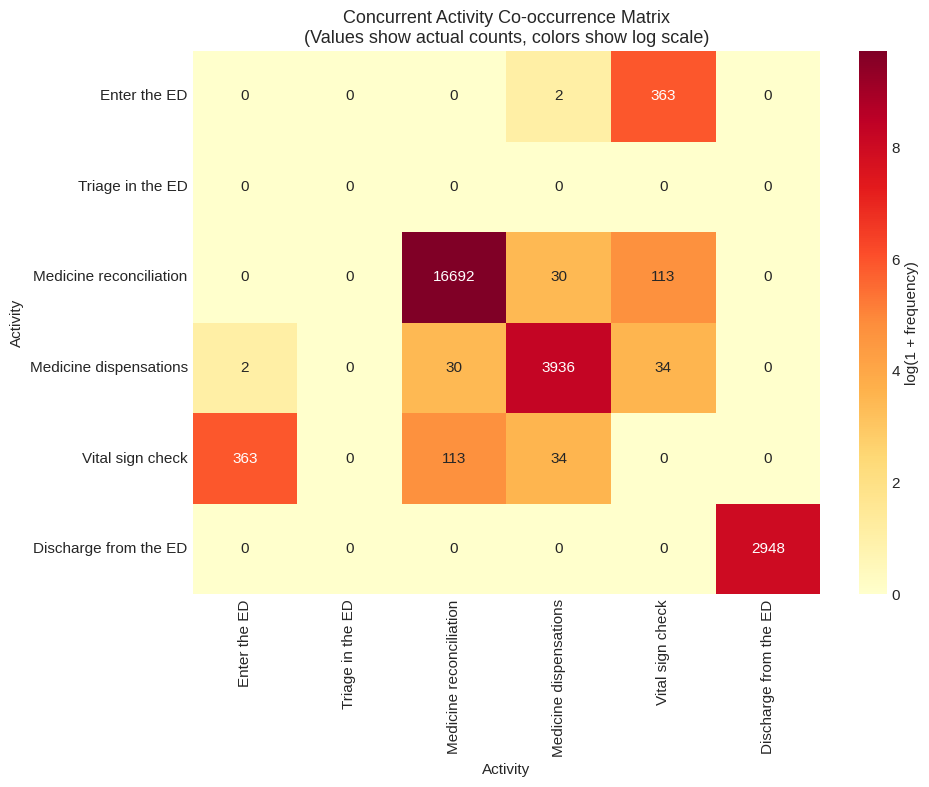

In [85]:
def detect_concurrent_activities(log):
    """
    Identify events occurring at exactly the same timestamp within a case.

    Concurrent activities are common in healthcare processes where:
    - Multiple medications are recorded at once
    - Batch processing occurs for administrative tasks
    - Multiple diagnoses are assigned simultaneously

    This affects temporal KPI calculations because:
    - Waiting time between concurrent events = 0
    - Traditional sequential assumptions don't hold

    Parameters:
    -----------
    log : pd.DataFrame
        Event log with case:concept:name, concept:name, and time:timestamp

    Returns:
    --------
    tuple
        (concurrent_df, concurrent_cases, concurrent_pairs)
        - concurrent_df: DataFrame with concurrent activity groups
        - concurrent_cases: Set of case IDs with concurrent activities
        - concurrent_pairs: Counter of activity pair co-occurrences
    """
    print("\n" + "="*80)
    print("STEP 3: CONCURRENT/PARALLEL ACTIVITIES DETECTION")
    print("="*80)
    print("""
    Identifying events at exactly the same timestamp within cases...
    Concurrent activities indicate parallel execution or batch recording.
    """)

    concurrent_events = []
    concurrent_cases = set()

    for case_id, case_df in log.groupby('case:concept:name'):
        # Group events by timestamp
        timestamp_groups = case_df.groupby('time:timestamp')

        for ts, group in timestamp_groups:
            if len(group) > 1:  # More than one event at same timestamp
                concurrent_cases.add(case_id)
                activities = group['concept:name'].tolist()
                concurrent_events.append({
                    'case_id': case_id,
                    'timestamp': ts,
                    'num_concurrent': len(group),
                    'activities': activities,
                    'activity_types': list(set(activities))
                })

    concurrent_df = pd.DataFrame(concurrent_events)

    # Analyze concurrent activity pairs
    concurrent_pairs = Counter()
    if len(concurrent_df) > 0:
        for _, row in concurrent_df.iterrows():
            activities = sorted(row['activities'])
            for i in range(len(activities)):
                for j in range(i+1, len(activities)):
                    concurrent_pairs[(activities[i], activities[j])] += 1

    # Calculate statistics
    total_cases = log['case:concept:name'].nunique()
    pct_concurrent = 100 * len(concurrent_cases) / total_cases

    # Report findings
    print(f"\n✓ RESULTS:")
    print(f"  - Cases with concurrent activities: {len(concurrent_cases):,} / {total_cases:,} ({pct_concurrent:.1f}%)")

    if len(concurrent_df) > 0:
        print(f"  - Total concurrent activity groups: {len(concurrent_df):,}")
        print(f"  - Average activities per concurrent group: {concurrent_df['num_concurrent'].mean():.2f}")
        print(f"  - Maximum concurrent activities: {concurrent_df['num_concurrent'].max()}")

        print("\n  Top 10 most common concurrent activity pairs:")
        for (act1, act2), count in concurrent_pairs.most_common(10):
            print(f"    {act1} ‖ {act2}: {count:,} times")

        print("""
    INTERPRETATION:
    - High concurrency suggests batch recording or parallel clinical activities
    - Same-activity concurrency (e.g., multiple Medicine reconciliation) indicates
      multiple instances of the same task (e.g., multiple medications)
    - Cross-activity concurrency suggests truly parallel processes
        """)

    return concurrent_df, concurrent_cases, concurrent_pairs

def create_concurrent_heatmap(concurrent_pairs, log):
    """
    Create a heatmap showing concurrent activity relationships.
    """
    activities = log['concept:name'].unique()
    n_activities = len(activities)

    # Create co-occurrence matrix
    matrix = pd.DataFrame(0, index=activities, columns=activities)
    for (a1, a2), count in concurrent_pairs.items():
        matrix.loc[a1, a2] = count
        matrix.loc[a2, a1] = count

    # Plot heatmap
    fig, ax = plt.subplots(figsize=(10, 8))

    # Use log scale for better visualization of varying magnitudes
    matrix_log = np.log1p(matrix)  # log(1+x) to handle zeros

    sns.heatmap(matrix_log, annot=matrix.values, fmt='g', cmap='YlOrRd',
                ax=ax, cbar_kws={'label': 'log(1 + frequency)'})

    ax.set_title('Concurrent Activity Co-occurrence Matrix\n(Values show actual counts, colors show log scale)')
    ax.set_xlabel('Activity')
    ax.set_ylabel('Activity')

    plt.tight_layout()
    plt.show()

concurrent_df, concurrent_cases, concurrent_pairs = detect_concurrent_activities(complete_log)
create_concurrent_heatmap(concurrent_pairs, complete_log)

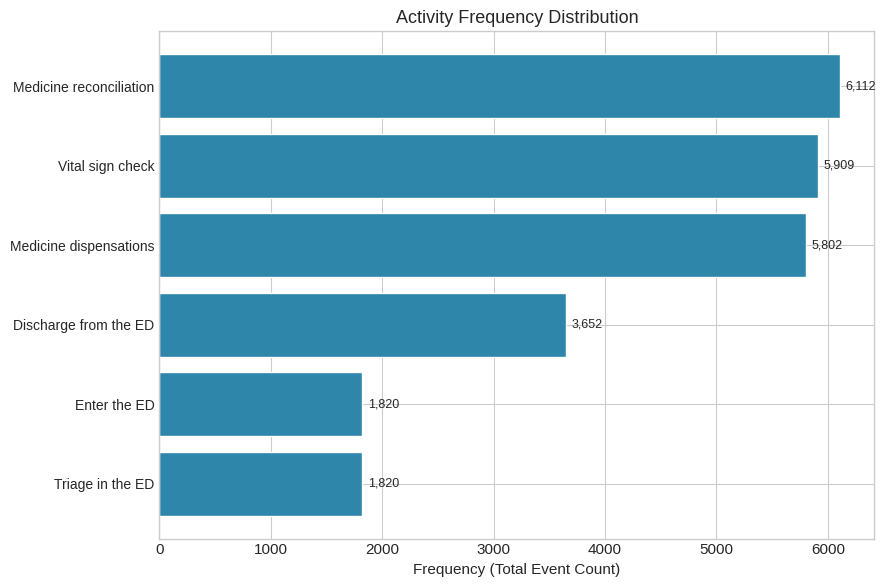

In [92]:
def plot_activity_frequency(log: pd.DataFrame, N: int = 15):
    """
    ## 📊 Top Activity Frequency

    Generates a horizontal bar chart of the top N most frequent activities.

    - **Input:** Event log (pandas DataFrame), N (integer, default 15) for top activities.
    - **Output:** Matplotlib Figure displaying the bar chart.
    """

    # Create a new figure and axes for the plot
    fig, ax = plt.subplots(figsize=(9, min(6, N * 0.5))) # Adjust height based on N

    activity_freq = log['concept:name'].value_counts()
    
    # Select the top N activities
    activity_freq_top = activity_freq.head(N)

    # Plotting the horizontal bars
    bars = ax.barh(range(len(activity_freq_top)), activity_freq_top.values,
            color=COLORS['primary'], edgecolor='white')

    # Setting y-axis labels
    ax.set_yticks(range(len(activity_freq_top)))
    ax.set_yticklabels(activity_freq_top.index, fontsize=10)
    
    # Setting labels and title
    ax.set_xlabel('Frequency (Total Event Count)')
    ax.set_title("Activity Frequency Distribution")
    ax.invert_yaxis() # Display the highest frequency bar at the top

    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars, activity_freq.values)):
        ax.text(val + 50, bar.get_y() + bar.get_height()/2, 
                f'{val:,}', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

plot_activity_frequency(complete_log)

## 2. Performance analysis

### 2.1 Concurrent activities detection

Identify events occurring at exactly the same timestamp within a case.
    
    Concurrent activities are common in healthcare processes where:
    - Multiple medications are recorded at once
    - Batch processing occurs for administrative tasks
    - Multiple diagnoses are assigned simultaneously
    
    This affects temporal KPI calculations because:
    - Waiting time between concurrent events = 0
    - Traditional sequential assumptions don't hold


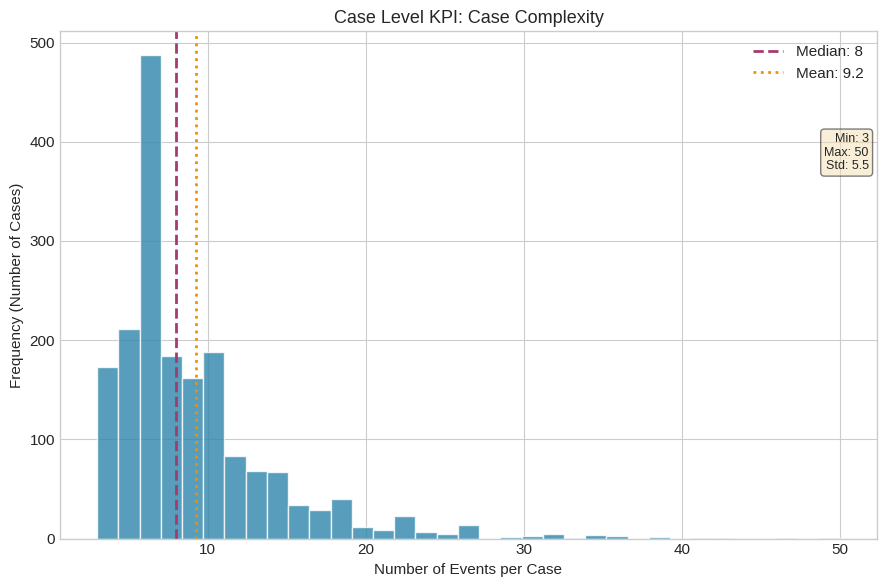

In [120]:
def plot_case_length_distribution(log: pd.DataFrame):
    """
    ## 📈 Case Length Distribution

    Generates a histogram showing the distribution of the number of events per case.

    - **Input:** Event log (pandas DataFrame).
    - **Output:** Matplotlib Figure displaying the histogram with key statistics 
      (Mean, Median, Min, Max, Std).
    """

    # Create a new figure and axes for the plot
    fig, ax = plt.subplots(figsize=(9, 6))

    events_per_case = log.groupby('case:concept:name').size()

    # Plotting the histogram
    ax.hist(events_per_case, bins=35, edgecolor='white', alpha=0.8,
            color=COLORS['primary'])

    # Adding mean and median lines
    median_val = events_per_case.median()
    mean_val = events_per_case.mean()

    ax.axvline(median_val, color=COLORS['secondary'],
               linestyle='--', linewidth=2, label=f'Median: {median_val:.0f}')
    ax.axvline(mean_val, color=COLORS['accent'],
               linestyle=':', linewidth=2, label=f'Mean: {mean_val:.1f}')

    # Setting labels and title
    ax.set_xlabel('Number of Events per Case')
    ax.set_ylabel('Frequency (Number of Cases)')
    ax.set_title('Case Level KPI: Case Complexity')
    ax.legend()

    # Add statistics annotation
    stats_text = (
        f'Min: {events_per_case.min()}\n'
        f'Max: {events_per_case.max()}\n'
        f'Std: {events_per_case.std():.1f}'
    )
    ax.text(0.99, 0.8, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.show()

plot_case_length_distribution(aggrgated_log)

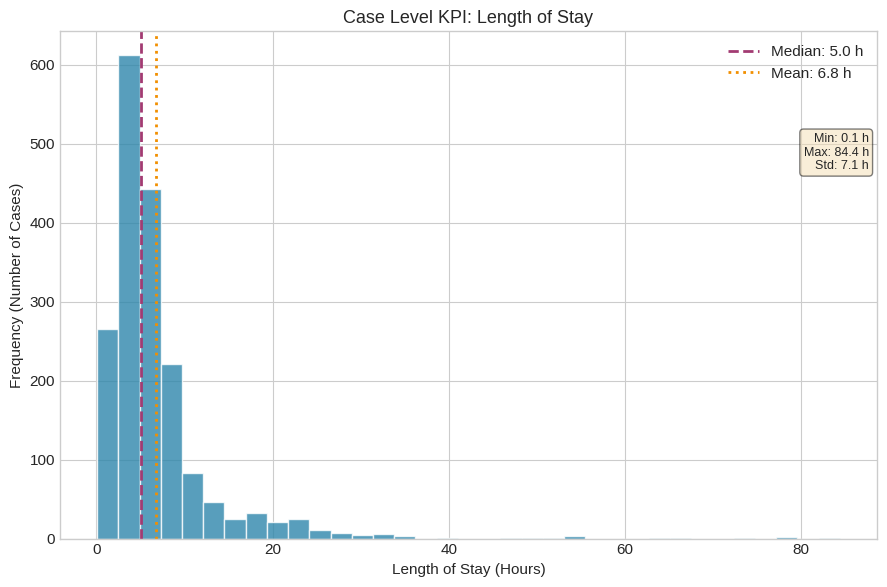

In [8]:
def plot_case_los_distribution(log: pd.DataFrame):
    """
    ## Case Length of Stay Distribution

    Calculates and plots the distribution of case length of Stay.
    Length of Stay is defined as the time difference between the
    first and last event of each case, measured in hours.

    - **Input:** Event log (pandas DataFrame)
    - **Output:** Matplotlib Figure with histogram and summary statistics
    """

    # Create figure
    fig, ax = plt.subplots(figsize=(9, 6))

    # Calculate Length of Stay per case
    case_times = log.groupby('case:concept:name')['time:timestamp']
    lead_time_hours = (
        case_times.max() - case_times.min()
    ).dt.total_seconds() / 3600

    # Plot histogram
    ax.hist(
        lead_time_hours,
        bins=35,
        edgecolor='white',
        alpha=0.8,
        color=COLORS['primary']
    )

    # Compute statistics
    median_val = lead_time_hours.median()
    mean_val = lead_time_hours.mean()

    # Add mean and median lines
    ax.axvline(
        median_val,
        color=COLORS['secondary'],
        linestyle='--',
        linewidth=2,
        label=f'Median: {median_val:.1f} h'
    )
    ax.axvline(
        mean_val,
        color=COLORS['accent'],
        linestyle=':',
        linewidth=2,
        label=f'Mean: {mean_val:.1f} h'
    )

    # Labels and title
    ax.set_xlabel('Length of Stay (Hours)')
    ax.set_ylabel('Frequency (Number of Cases)')
    ax.set_title('Case Level KPI: Length of Stay')
    ax.legend()

    # Statistics annotation
    stats_text = (
        f'Min: {lead_time_hours.min():.1f} h\n'
        f'Max: {lead_time_hours.max():.1f} h\n'
        f'Std: {lead_time_hours.std():.1f} h'
    )
    ax.text(
        0.99, 0.8,
        stats_text,
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    )

    plt.tight_layout()
    plt.show()

plot_case_los_distribution(complete_log)